# Sample 02: optimize a telescope pointing

This sample demonstrates a minimal astrometric calibration with Optax. We generate noisy detector measurements with the distortion-free gnomonic model, perturb the telescope pointing, and recover its right ascension, declination, and position angle.

Only `Astrometry.exposure.pointing` is optimized. The source catalog, telescope optics, detector geometry, and exposure calibration remain fixed.

## 1. Imports and plotting configuration

Warpfield provides the differentiable forward model and small adapters for selecting PyTree parameters. Optax supplies the Adam optimizer, while Equinox compiles the update step.

In [1]:
from astropy.coordinates import SkyCoord
from astropy.table import QTable
import astropy.units as u
import equinox as eqx
import matplotlib.pyplot as plt
import numpy as np
import optax

from warpfield import Astrometry, Exposure, Pointing, SourceCatalog
from warpfield.model import get_gnomonic
from warpfield.optim import set_parameters
from warpfield.optim.optax import initialize, step

plt.rcParams['figure.dpi'] = 72
plt.rcParams['legend.frameon'] = False

## 2. Construct a source catalog

We place an $9 \times 9$ regular source grid around $(\alpha, \delta) = (100°, 20°)$. Astropy's sky-offset frame constructs the grid on the celestial sphere before it is converted into the ICRS coordinates stored by `SourceCatalog`.

In [2]:
true_ra = 100.0
true_dec = 20.0
true_pa = 12.0

center = SkyCoord(true_ra * u.deg, true_dec * u.deg, frame='icrs')
grid = np.linspace(-0.35, 0.35, 9)
offset_x, offset_y = np.meshgrid(grid, grid)
sky = SkyCoord(
  lon=offset_x.ravel() * u.deg,
  lat=offset_y.ravel() * u.deg,
  frame=center.skyoffset_frame(),
).icrs

source = SourceCatalog(sky.ra.degree, sky.dec.degree)
print(f'{len(source)} catalog sources')

81 catalog sources


## 3. Generate noisy measurements

`get_gnomonic(simulator=True)` returns a distortion-free telescope with one centered 4096 × 4096 detector. Its angular pixel scale is one arcsecond per pixel. The `Simulator` applies the field-of-view and detector masks and returns a `Measurement` containing the surviving detector coordinates and their source, exposure, and detector indices.

We request independent Gaussian errors with a standard deviation of 0.01 pixel. `seed=42` makes the realization reproducible, and `Simulator.observe()` stores the same standard deviation in `Measurement.uncertainty` for use by the weighted least-squares objective.

In [3]:
telescope = get_gnomonic(simulator=True)
true_pointing = Pointing([true_ra], [true_dec], [true_pa])
true_exposure = Exposure(true_pointing)
measurement = telescope.observe(source, true_exposure, error=0.01, seed=42)

print(f'{len(measurement)} measurements')
print('Detector-coordinate range:')
print(
  '  x:',
  float(measurement.xy[:, 0].min()),
  'to',
  float(measurement.xy[:, 0].max()),
  'pixel',
)
print(
  '  y:',
  float(measurement.xy[:, 1].min()),
  'to',
  float(measurement.xy[:, 1].max()),
  'pixel',
)

81 measurements
Detector-coordinate range:
  x: 553.5455033811986 to 3542.4500547158395 pixel
  y: 553.5133081654748 to 3542.469039732796 pixel


## 4. Define an initial pointing

The initial right ascension is displaced by +10 arcseconds, declination by −8 arcseconds, and position angle by +0.2 degrees. `Astrometry` combines this trial exposure with the fixed source catalog and telescope. Its residual is observed minus predicted detector position.

In [4]:
initial_pointing = Pointing(
  [true_ra + 10.0 / 3600],
  [true_dec - 8.0 / 3600],
  [true_pa + 0.2],
)
astrometry = Astrometry(
  source,
  telescope,
  Exposure(initial_pointing),
)

initial_residual = np.asarray(astrometry.residual(measurement))
initial_rms = np.sqrt(np.mean(initial_residual**2))
print(f'Initial residual RMS: {initial_rms:.3f} pixel')

Initial residual RMS: 9.173 pixel


The arrows below show the initial detector residuals. Their coherent pattern contains a translation from the right-ascension and declination errors and a rotation from the position-angle error.

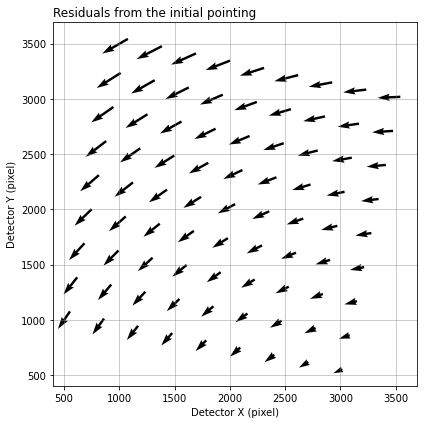

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(
  np.asarray(measurement.xy[:, 0]),
  np.asarray(measurement.xy[:, 1]),
  initial_residual[:, 0],
  initial_residual[:, 1],
  angles='xy',
  scale_units='xy',
)
ax.set_aspect(1.0, adjustable='box')
ax.grid(True, color='gray', alpha=0.5)
ax.set_xlabel('Detector X (pixel)')
ax.set_ylabel('Detector Y (pixel)')
ax.set_title('Residuals from the initial pointing', loc='left')
fig.tight_layout()
plt.show()

## 5. Select and optimize the pointing parameters

Zodiax paths identify the three trainable PyTree leaves. Because no source or telescope path is selected, those parts of `Astrometry` cannot be changed by the optimizer. `initialize()` extracts the selected arrays and creates the Optax state.

The helper `step()` divides each residual by `Measurement.uncertainty`, evaluates the weighted least-squares loss, differentiates it with JAX, and applies one Optax update. We JIT-compile that operation and run 300 Adam steps.

In [6]:
paths = (
  'exposure.pointing.ra',
  'exposure.pointing.dec',
  'exposure.pointing.position_angle',
)
optimizer = optax.adam(learning_rate=1.0e-2)
parameters, optimizer_state = initialize(astrometry, paths, optimizer)
step_jit = eqx.filter_jit(step)

losses = []
for iteration in range(300):
  parameters, optimizer_state, loss = step_jit(
    parameters,
    optimizer_state,
    optimizer,
    astrometry,
    measurement,
  )
  losses.append(float(loss))

fitted = set_parameters(astrometry, parameters)

## 6. Inspect the result

The loss decreases by many orders of magnitude. The fitted values recover the true pointing within the measurement uncertainty, while the final detector residuals approach the 0.01-pixel noise floor rather than zero.

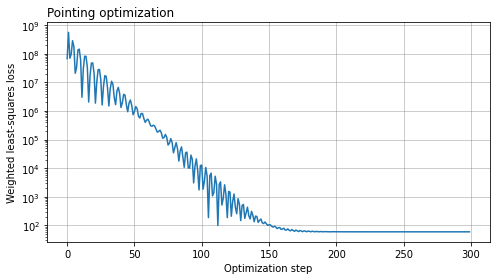

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(losses)
ax.grid(True, color='gray', alpha=0.5)
ax.set_xlabel('Optimization step')
ax.set_ylabel('Weighted least-squares loss')
ax.set_title('Pointing optimization', loc='left')
fig.tight_layout()
plt.show()

In [8]:
fitted_pointing = fitted.exposure.pointing
result = QTable({
  'parameter': ['ra', 'dec', 'position_angle'],
  'truth': [true_ra, true_dec, true_pa] * u.deg,
  'initial': [
    float(initial_pointing.ra[0]),
    float(initial_pointing.dec[0]),
    float(initial_pointing.position_angle[0]),
  ]
  * u.deg,
  'fitted': [
    float(fitted_pointing.ra[0]),
    float(fitted_pointing.dec[0]),
    float(fitted_pointing.position_angle[0]),
  ]
  * u.deg,
})
result

parameter,truth,initial,fitted
,deg,deg,deg
str14,float64,float64,float64
ra,100.0,100.00277777777778,99.99999985795473
dec,20.0,19.997777777777777,20.000000246307266
position_angle,12.0,12.2,12.000008388645876


In [9]:
final_residual = np.asarray(fitted.residual(measurement))
final_rms = np.sqrt(np.mean(final_residual**2))

print(f'Initial residual RMS: {initial_rms:.6f} pixel')
print(f'Final residual RMS:   {final_rms:.6e} pixel')

Initial residual RMS: 9.173280 pixel
Final residual RMS:   8.607263e-03 pixel


## Summary

- `Simulator.observe()` generates indexed detector measurements and can add reproducible Gaussian errors with corresponding uncertainties.
- `Astrometry` evaluates residuals with the source catalog, telescope, and exposure as one differentiable PyTree.
- Zodiax parameter paths restrict optimization to the three `Pointing` arrays.
- Optax updates only the extracted parameters; `set_parameters()` then constructs the fitted `Astrometry` object.
- `Measurement.uncertainty` converts the objective into weighted least squares; consequently, fitted residuals remain at the simulated noise floor rather than converging to zero.